# Deep SRQ PATH LCP Pool Training

Training-only notebook for Deep SRQ with the `path_c_pool` stage-game solver using 8 worker processes. Each epsilon cell runs all configured LBF scenarios and saves full-resume checkpoints plus reward plots.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]

for path in [REPO_ROOT, REPO_ROOT / "discrete_action_space", REPO_ROOT / "discrete_action_space" / "lbf_grid"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from discrete_action_space.lbf_grid.robust_notebook_utils import (
    DEFAULT_EVAL_EPISODES,
    ROBUST_EPSILONS,
    evaluate_deepsrq_path_mcp_pool_suite_for_epsilon,
    robust_lbf_scenarios,
    train_deepsrq_path_mcp_pool_for_epsilon,
)
from discrete_action_space.lbf_grid.notebook_eval import display_training_reward_plots

SCENARIOS = robust_lbf_scenarios()

def newly_trained_records(records):
    return [record for record in records if record.get("status") != "skipped_existing"]


In [2]:
N_EPISODES = 3000
USE_GPU = True
BASE_SEED = 2025
EVAL_INTERVAL = 100
EVAL_EPISODES_DURING_TRAINING = 30
NUM_ENVS = 32
EVAL_NUM_ENVS = 8
SRE_SOLVER_WORKERS = 16
SKIP_EXISTING_TRAINING = True
USE_ACTION_MASKS = True
PATH_POOL_SOLVER = "path_c_pool"
PATH_C_HYPERPARAMETER_OVERRIDES = {
    "agent": {
        "sre_num_random_starts": 5,
        "sre_num_pure_starts": 10,
        "train_every": 4,
        "target_equilibrium_update_steps": 4,
        "sre_policy_cache_enabled": True,
    },
}


## Robust epsilon 0.01

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.01 | schedule=constant | seed=2026 | num_envs=32 | action_masks=True | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.01_constant:vec:   4%|█▋                                        | 117/3000 [01:01<22:08,  2.17it/s]

[ep   100] train_joint=  0.2178 | eval_joint=  0.0704 | best_loss=0.001877 | latest_loss=0.002104 | solver_mean_ms=24.836


lbf:path_c_pool_eps0.01_constant:vec:   7%|███                                       | 217/3000 [01:49<19:34,  2.37it/s]

[ep   200] train_joint=  0.2000 | eval_joint=  0.0333 | best_loss=0.000687 | latest_loss=0.004568 | solver_mean_ms=24.025


...

[ep  2900] train_joint=  0.3261 | eval_joint=  0.1741 | best_loss=0.000020 | latest_loss=0.000363 | solver_mean_ms=18.587


lbf:path_c_pool_eps0.01_constant:vec:  99%|████████████████████████████████████████▋| 2977/3000 [24:11<00:14,  1.59it/s]

[ep  3000] train_joint=  0.3833 | eval_joint=  0.1481 | best_loss=0.000020 | latest_loss=0.000052 | solver_mean_ms=18.625


lbf:path_c_pool_eps0.01_constant:vec: 100%|█████████████████████████████████████████| 3000/3000 [24:15<00:00,  2.06it/s]



Reward Summary
Scenario                                                                                                         | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 0.09 | 0.07 | 0.11             | 0.07            | 3000    
2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 0.21 | 0.13 | 0.27             | 0.15            | 3000    
DeepSRQ PATH pool lbf_8x8_2p_2f_levels12 solver=path_c_pool run=0.01 ep=3000 best_loss=1.989932388823945e-05 latest_loss=5.1

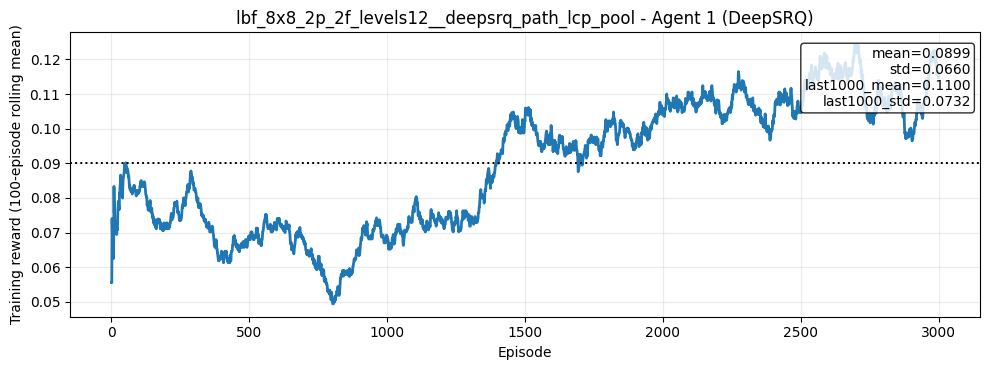

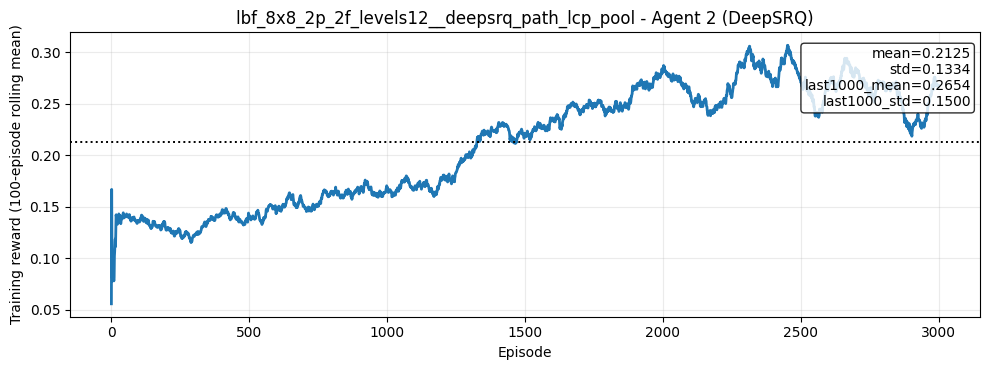

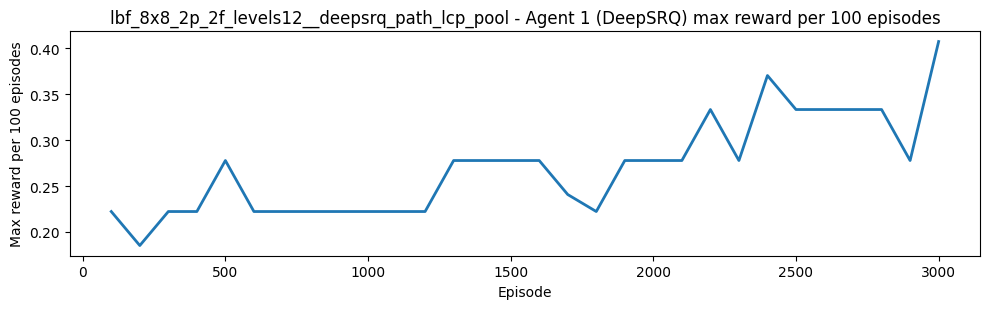

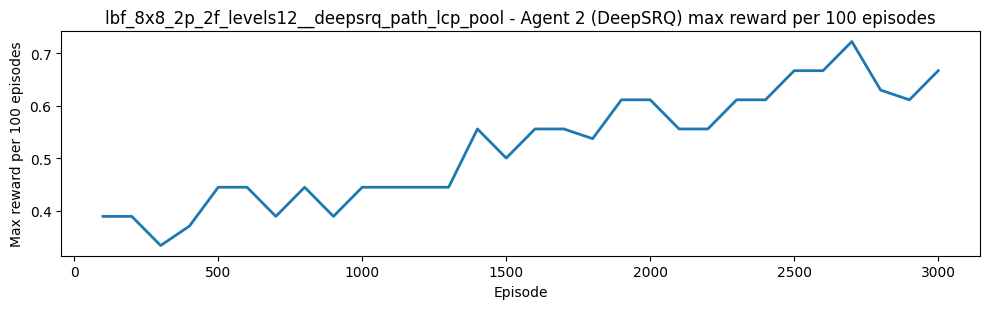

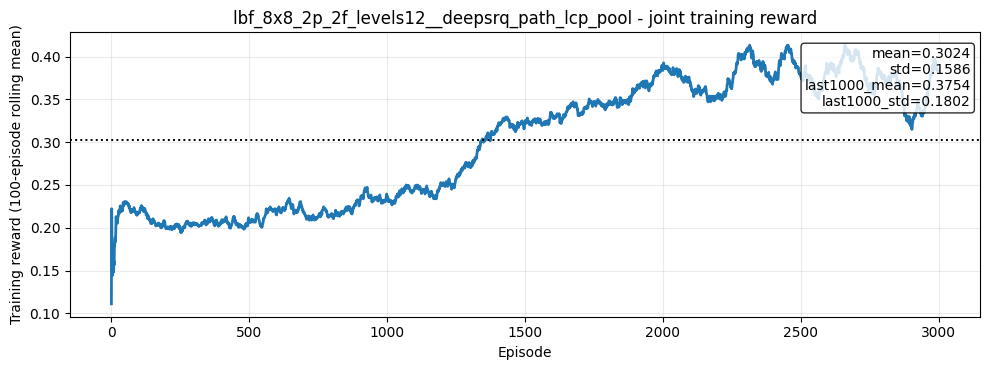

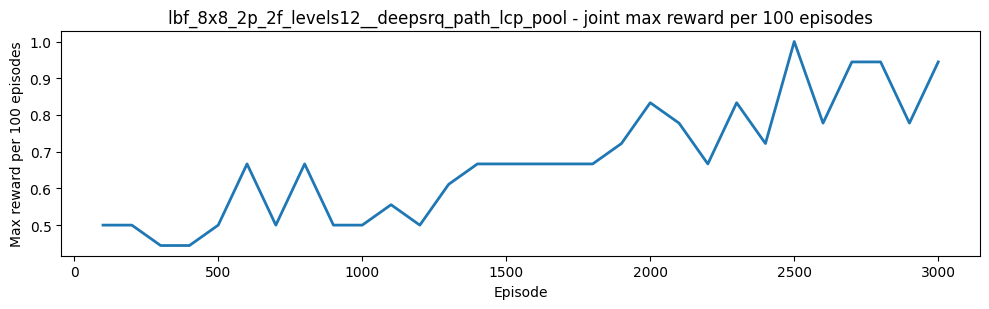

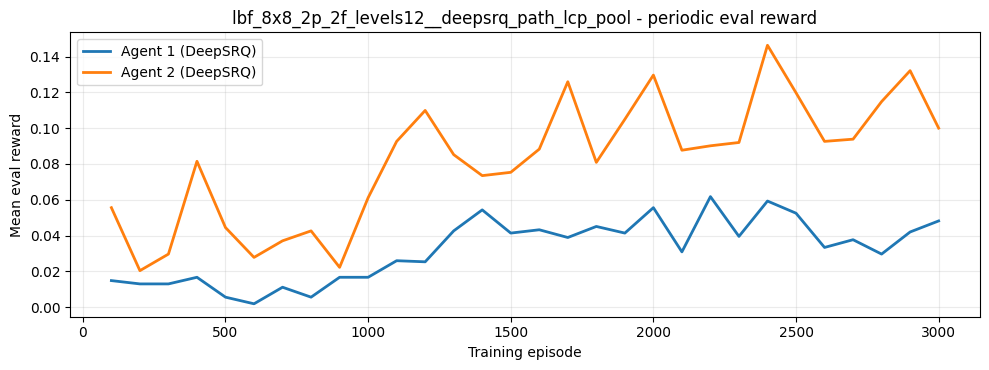

In [3]:
deep_srq_path_pool_eps_0_01_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.01,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 1,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_SOLVER,
    hyperparameter_overrides=PATH_C_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
)
deep_srq_path_pool_eps_0_01_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_01_stats.values()))


## Robust epsilon 0.1

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.1 | schedule=constant | seed=2035 | num_envs=32 | action_masks=True | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.1_constant:vec:   4%|█▋                                         | 116/3000 [00:59<23:15,  2.07it/s]

[ep   100] train_joint=  0.1989 | eval_joint=  0.0519 | best_loss=0.002127 | latest_loss=0.002923 | solver_mean_ms=23.434


lbf:path_c_pool_eps0.1_constant:vec:   7%|███                                        | 215/3000 [01:49<21:14,  2.19it/s]

[ep   200] train_joint=  0.1972 | eval_joint=  0.0241 | best_loss=0.000909 | latest_loss=0.005148 | solver_mean_ms=22.846


...

[ep  2900] train_joint=  0.2293 | eval_joint=  0.1044 | best_loss=0.000011 | latest_loss=0.000052 | solver_mean_ms=19.882


lbf:path_c_pool_eps0.1_constant:vec:  99%|█████████████████████████████████████████▋| 2980/3000 [24:44<00:11,  1.80it/s]

[ep  3000] train_joint=  0.2120 | eval_joint=  0.1267 | best_loss=0.000010 | latest_loss=0.000213 | solver_mean_ms=19.926


lbf:path_c_pool_eps0.1_constant:vec: 100%|██████████████████████████████████████████| 3000/3000 [24:48<00:00,  2.02it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 0.09 | 0.08 | 0.12             | 0.09            | 3000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 0.09 | 0.08 | 0.12             | 0.09            | 3000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=0.1 ep=3000 best_loss=1.0254326298309024e-05 latest_loss=0.00021302339

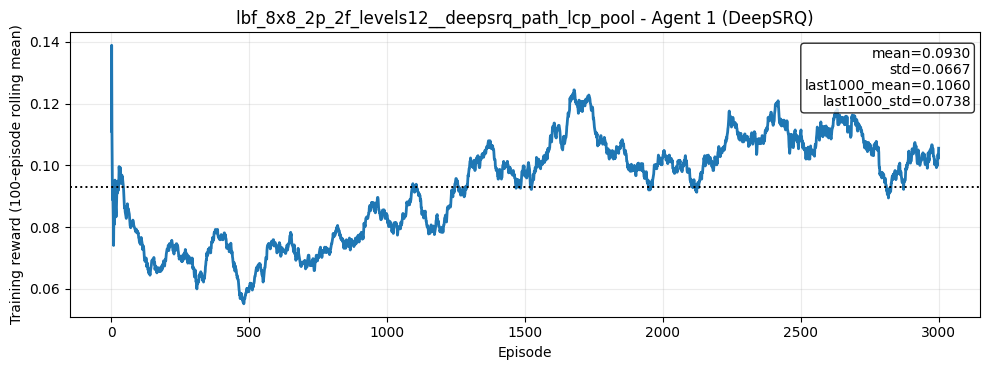

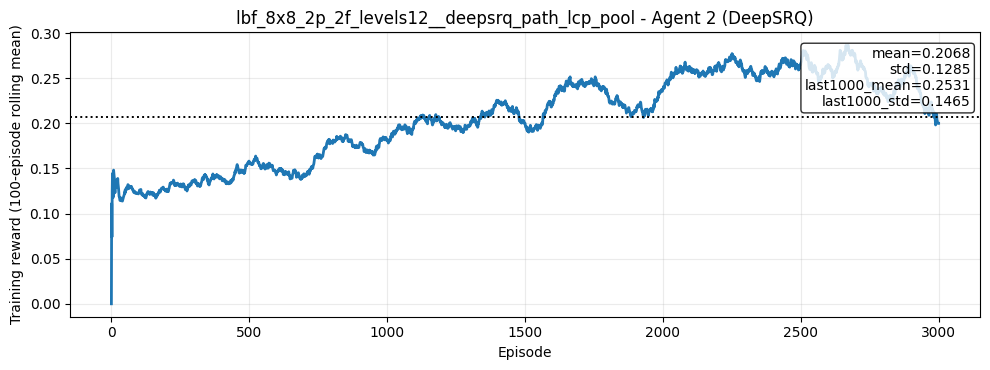

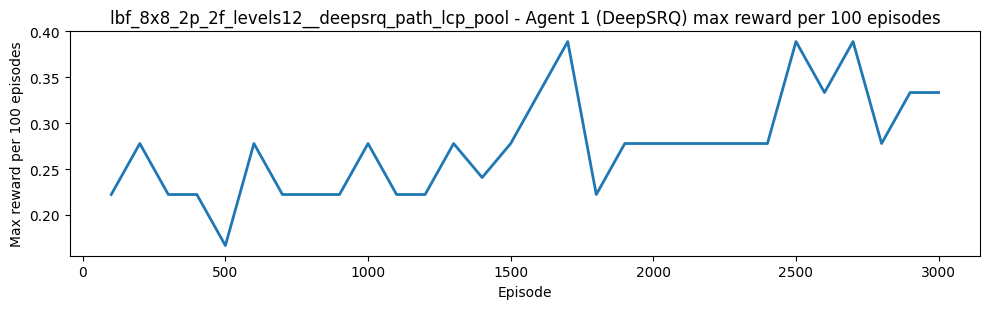

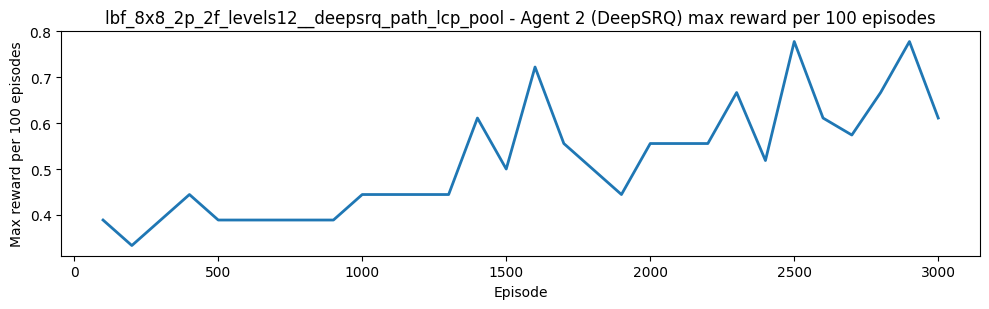

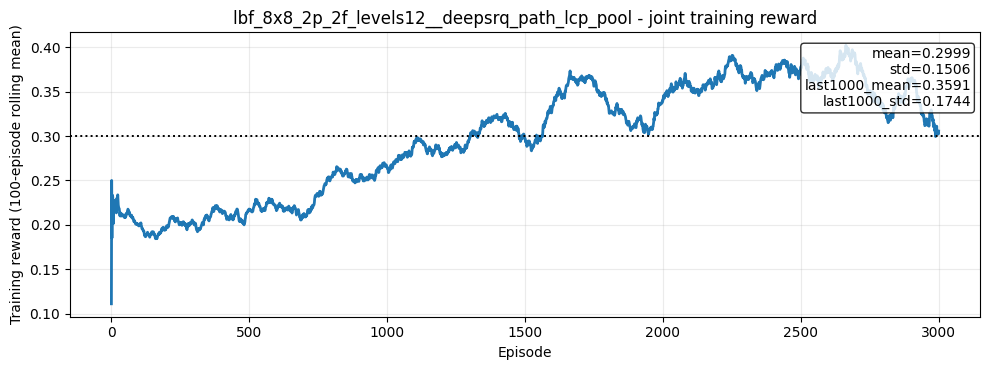

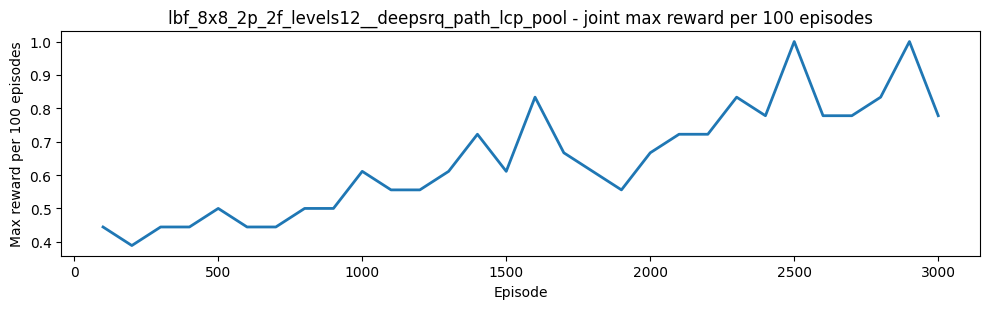

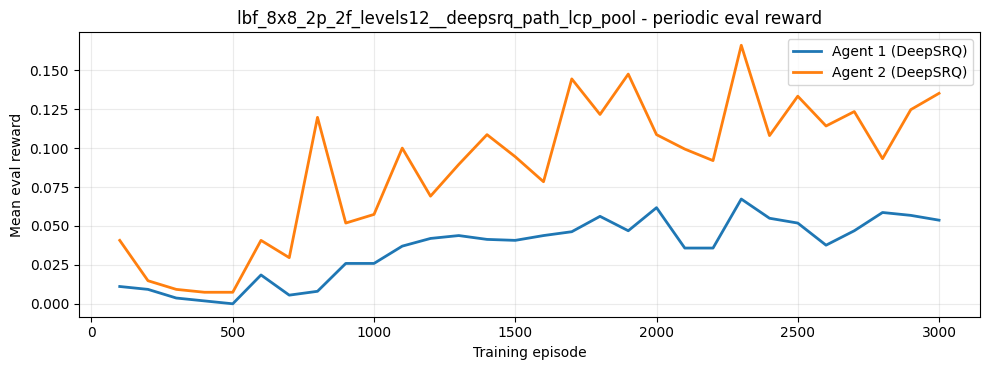

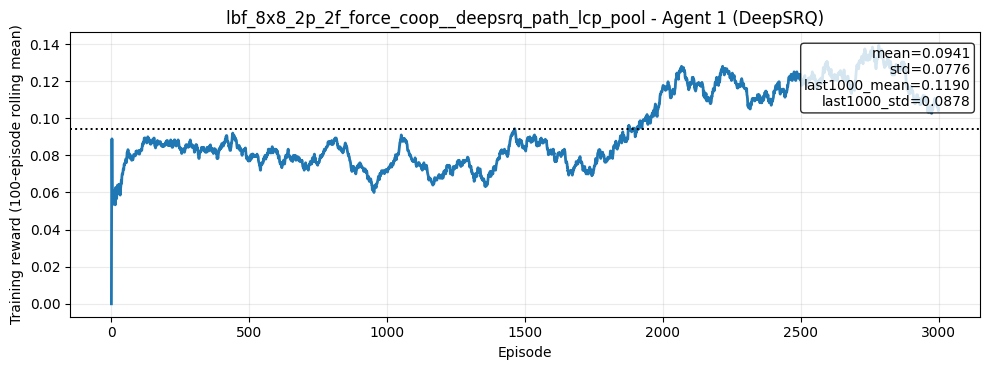

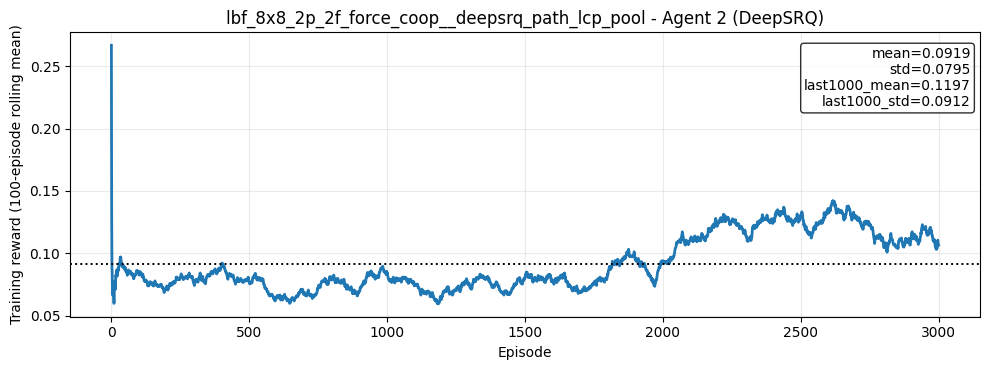

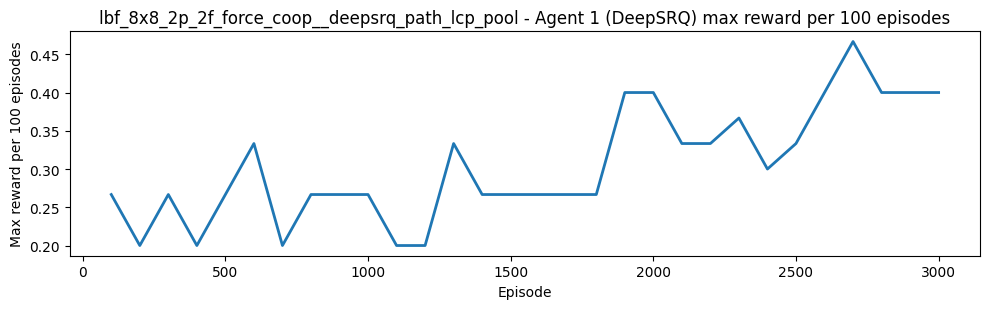

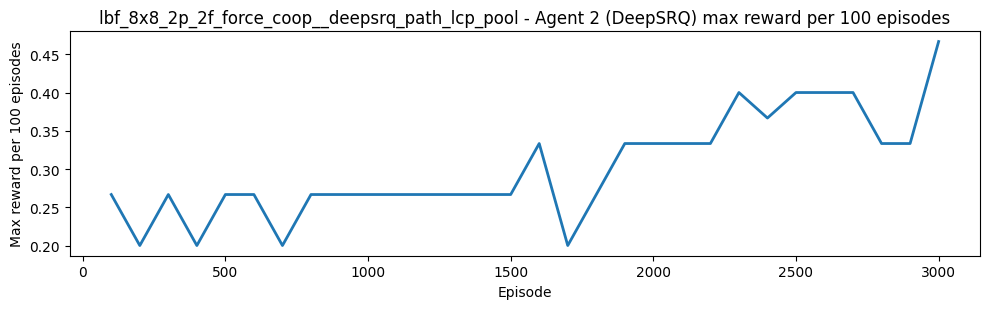

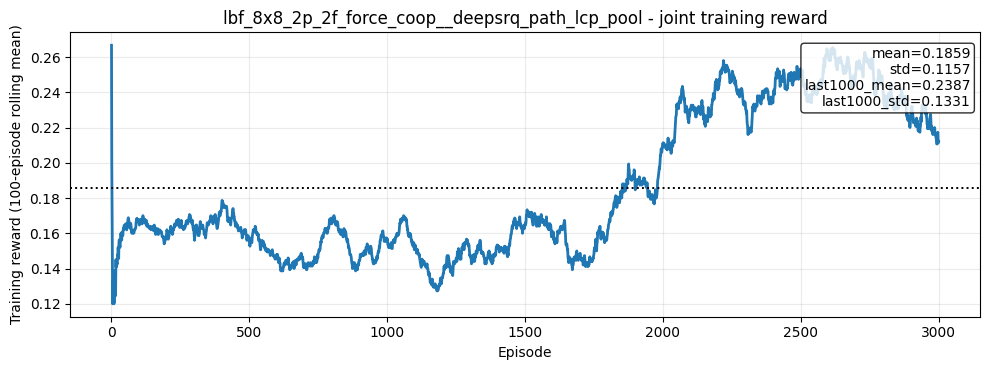

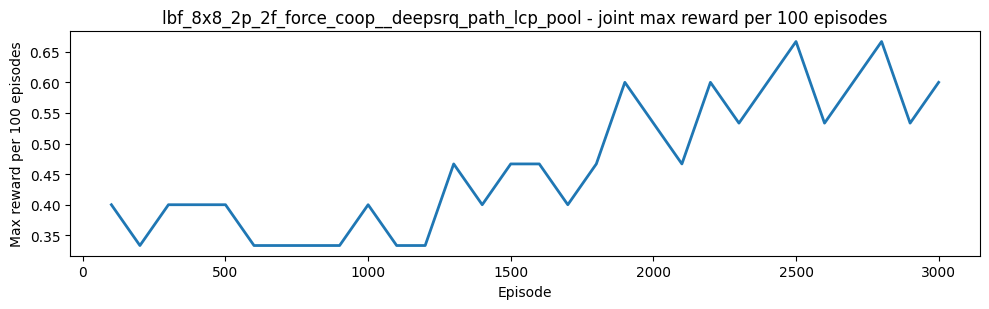

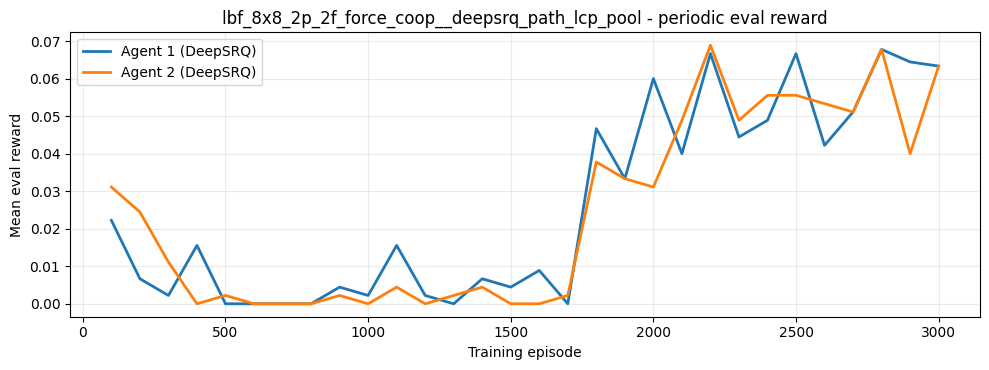

In [4]:
deep_srq_path_pool_eps_0_1_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.1,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 10,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_SOLVER,
    hyperparameter_overrides=PATH_C_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
)
deep_srq_path_pool_eps_0_1_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_1_stats.values()))


## Robust epsilon 0.5

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.5 | schedule=constant | seed=2075 | num_envs=32 | action_masks=True | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.5_constant:vec:   4%|█▋                                         | 116/3000 [01:00<24:11,  1.99it/s]

[ep   100] train_joint=  0.2006 | eval_joint=  0.1241 | best_loss=0.001222 | latest_loss=0.008846 | solver_mean_ms=23.146


lbf:path_c_pool_eps0.5_constant:vec:   7%|███                                        | 216/3000 [01:52<20:57,  2.21it/s]

[ep   200] train_joint=  0.2000 | eval_joint=  0.1333 | best_loss=0.000684 | latest_loss=0.002553 | solver_mean_ms=22.788


...

[ep  2900] train_joint=  0.2280 | eval_joint=  0.1156 | best_loss=0.000009 | latest_loss=0.000116 | solver_mean_ms=19.299


lbf:path_c_pool_eps0.5_constant:vec:  99%|█████████████████████████████████████████▋| 2980/3000 [24:59<00:11,  1.71it/s]

[ep  3000] train_joint=  0.1880 | eval_joint=  0.1200 | best_loss=0.000009 | latest_loss=0.000304 | solver_mean_ms=19.360


lbf:path_c_pool_eps0.5_constant:vec: 100%|██████████████████████████████████████████| 3000/3000 [25:03<00:00,  2.00it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 0.10 | 0.08 | 0.12             | 0.09            | 3000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 0.10 | 0.08 | 0.13             | 0.09            | 3000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=0.5 ep=3000 best_loss=8.97944573807763e-06 latest_loss=0.0003035434638

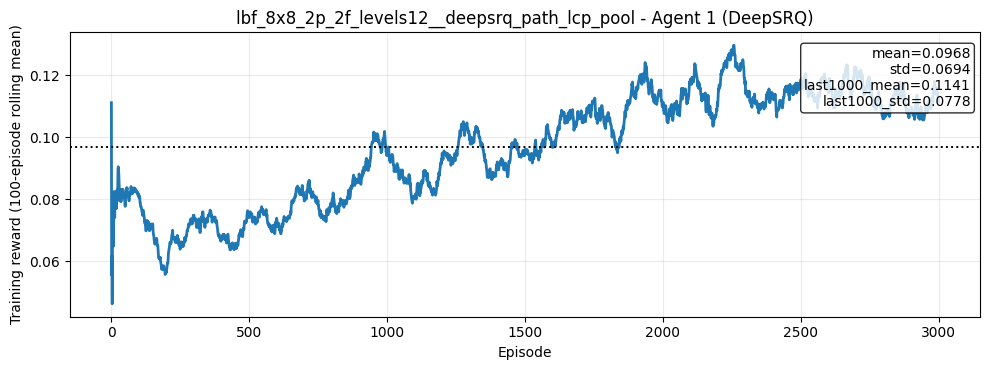

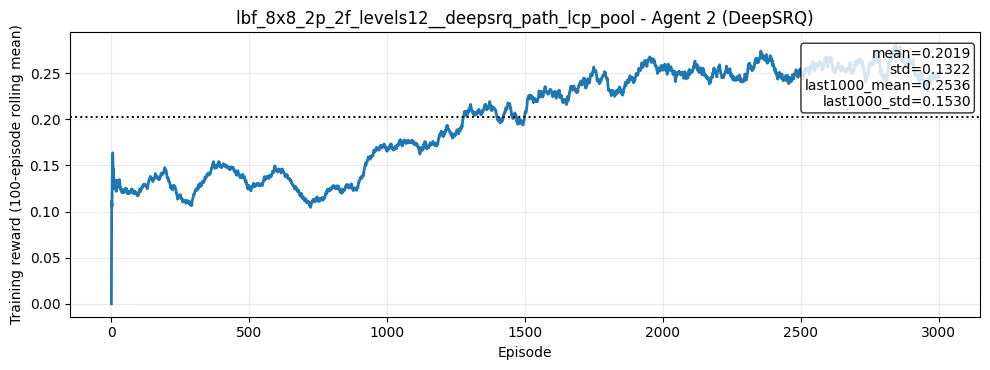

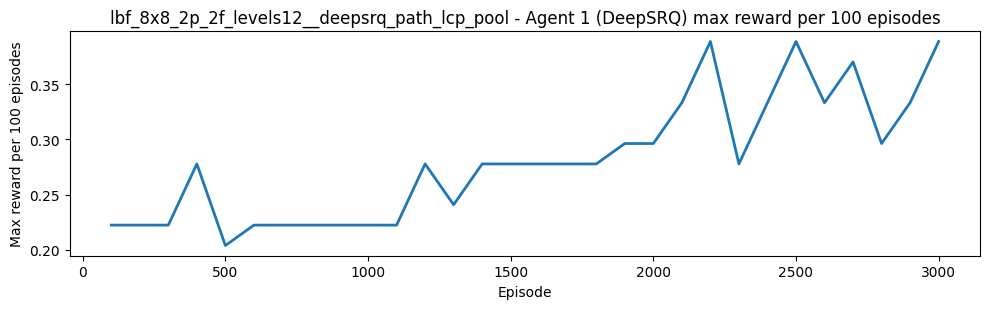

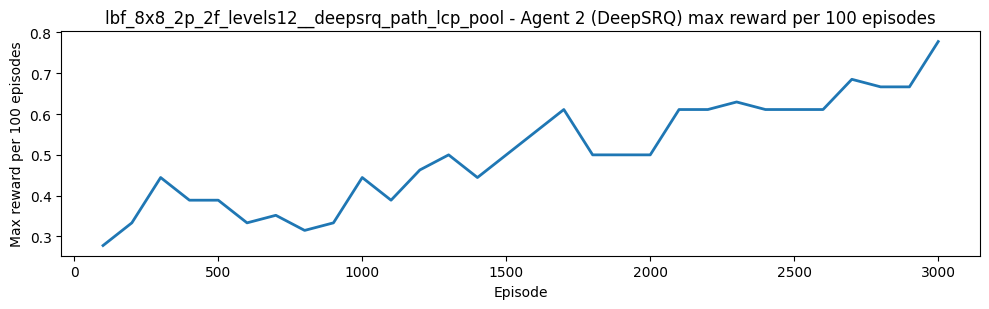

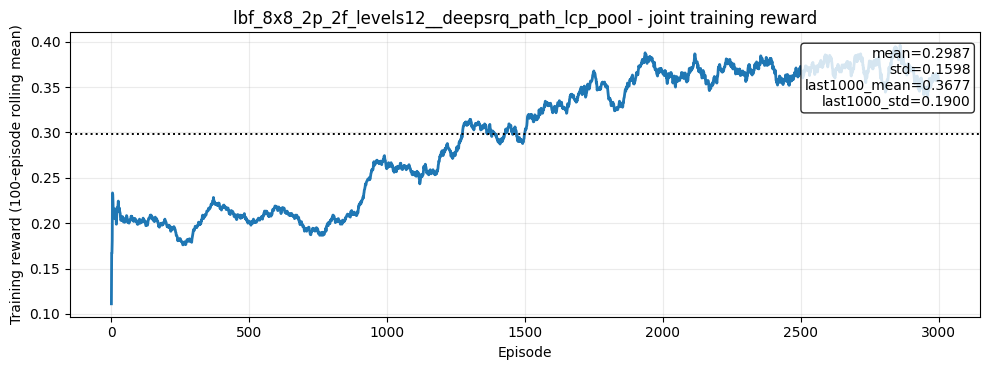

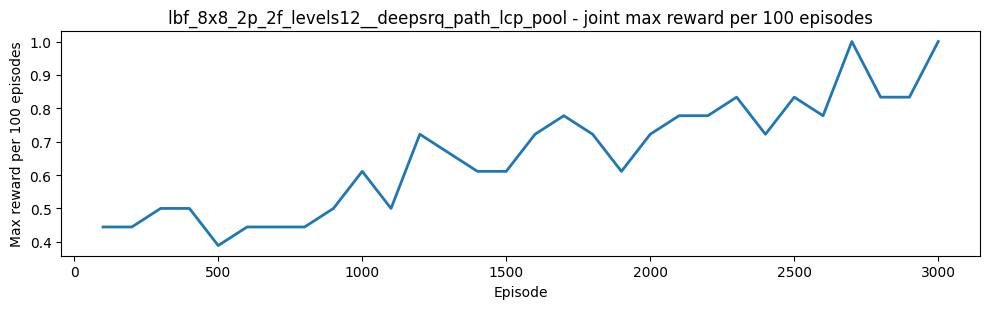

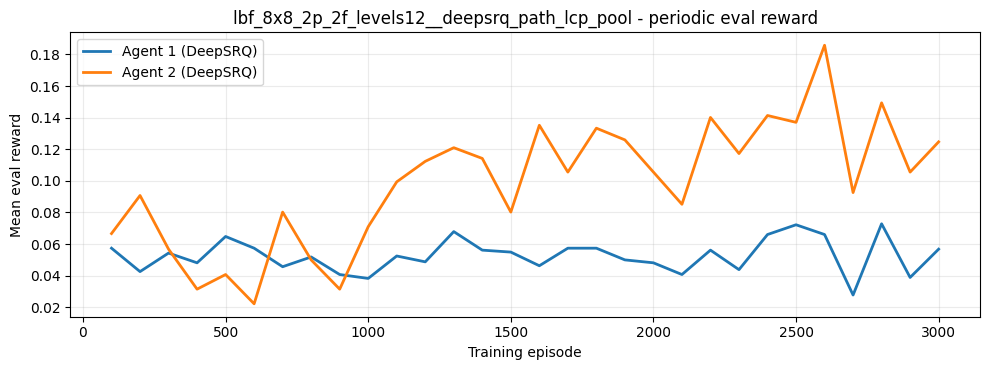

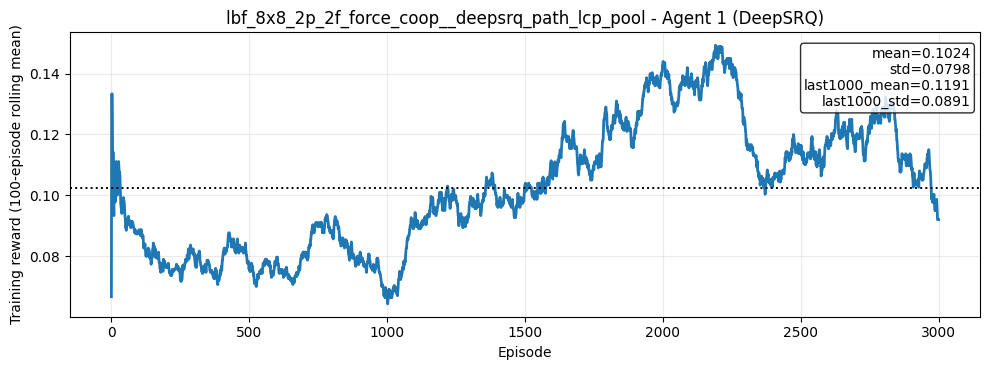

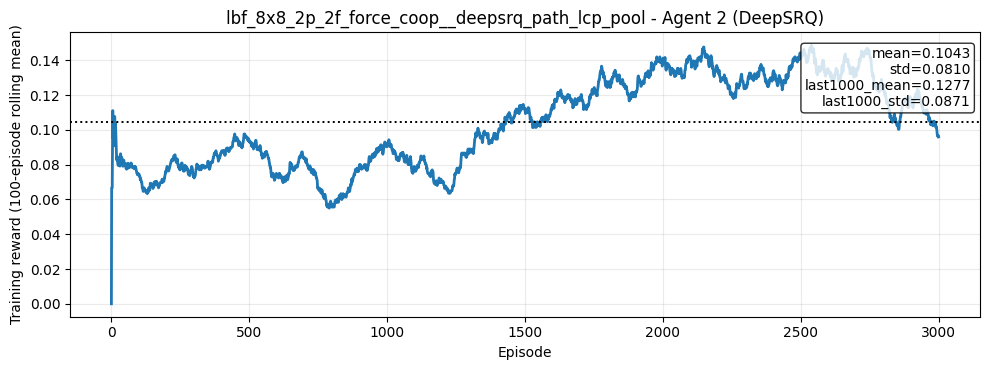

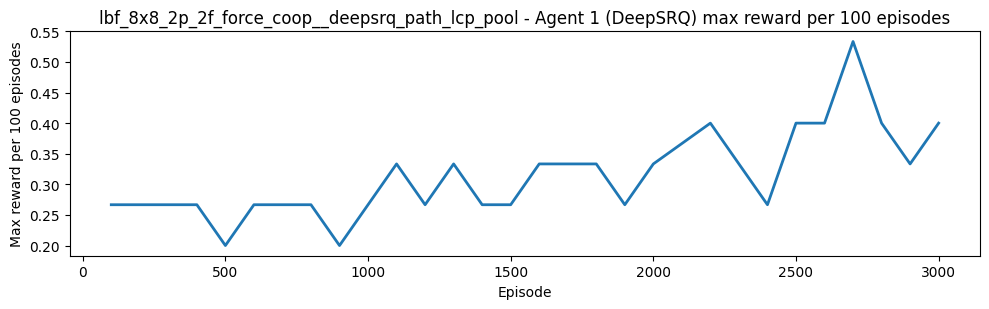

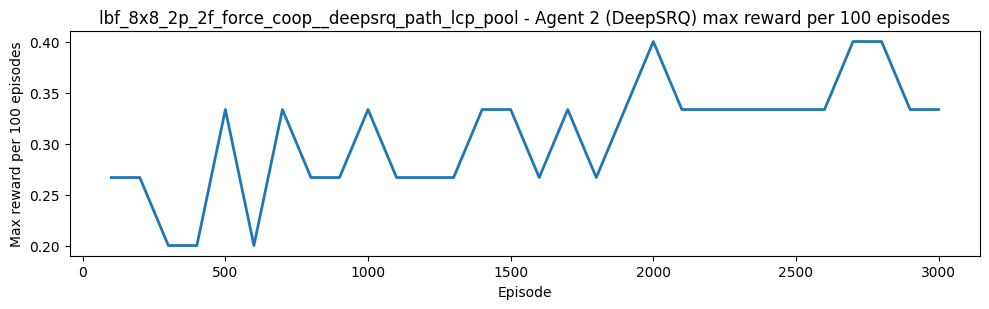

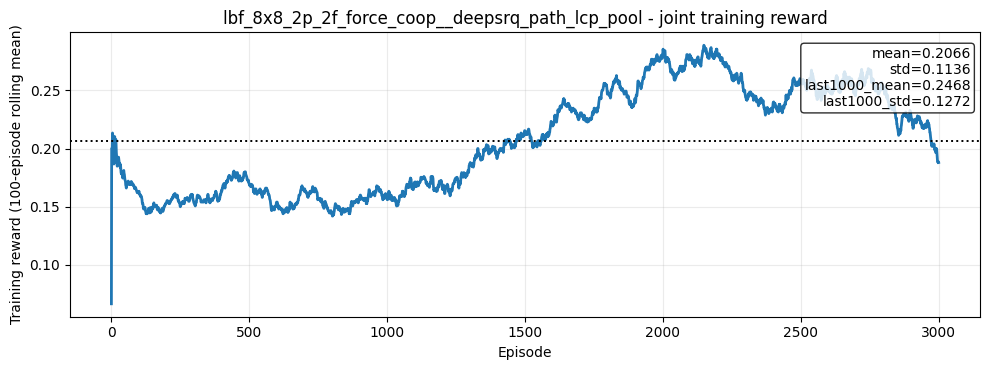

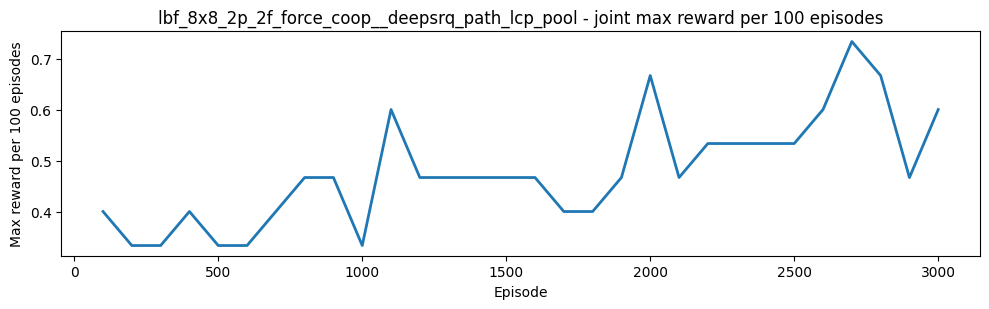

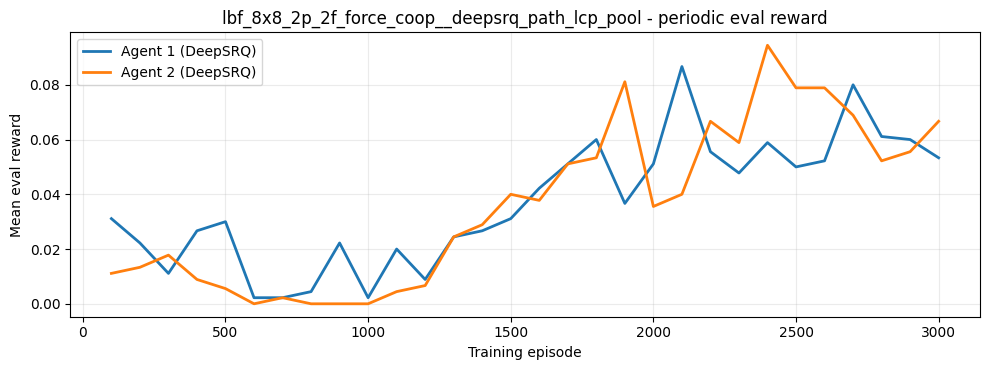

In [5]:
deep_srq_path_pool_eps_0_5_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.5,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 50,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_SOLVER,
    hyperparameter_overrides=PATH_C_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
)
deep_srq_path_pool_eps_0_5_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_5_stats.values()))


## Robust epsilon 1

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=1 | schedule=constant | seed=2125 | num_envs=32 | action_masks=True | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps1_constant:vec:   4%|█▋                                           | 116/3000 [01:00<22:03,  2.18it/s]

[ep   100] train_joint=  0.2211 | eval_joint=  0.1111 | best_loss=0.000905 | latest_loss=0.001397 | solver_mean_ms=22.136


lbf:path_c_pool_eps1_constant:vec:   7%|███▏                                         | 214/3000 [01:54<23:38,  1.96it/s]

[ep   200] train_joint=  0.2161 | eval_joint=  0.2019 | best_loss=0.000503 | latest_loss=0.001072 | solver_mean_ms=21.618


...

[ep  2900] train_joint=  0.2173 | eval_joint=  0.1311 | best_loss=0.000007 | latest_loss=0.000237 | solver_mean_ms=18.742


lbf:path_c_pool_eps1_constant:vec:  99%|███████████████████████████████████████████▋| 2978/3000 [24:51<00:12,  1.70it/s]

[ep  3000] train_joint=  0.2167 | eval_joint=  0.1533 | best_loss=0.000007 | latest_loss=0.000171 | solver_mean_ms=18.792


lbf:path_c_pool_eps1_constant:vec: 100%|████████████████████████████████████████████| 3000/3000 [24:56<00:00,  2.00it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 0.10 | 0.08 | 0.12             | 0.09            | 3000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 0.11 | 0.08 | 0.12             | 0.09            | 3000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=1.0 ep=3000 best_loss=7.021424607955851e-06 latest_loss=0.000171294726

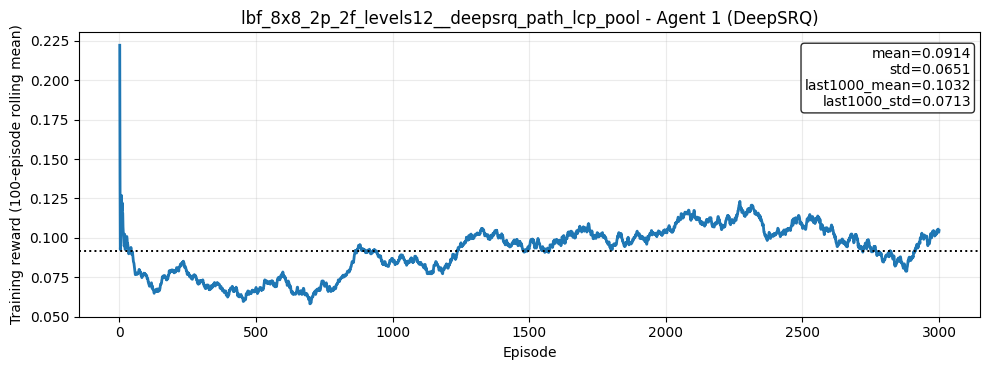

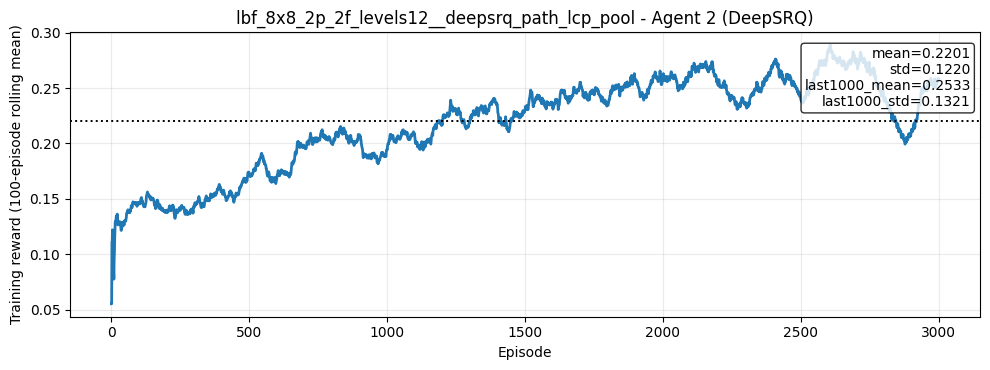

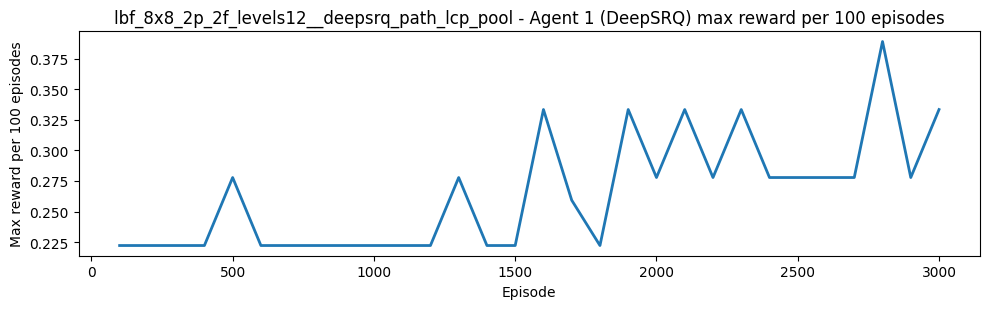

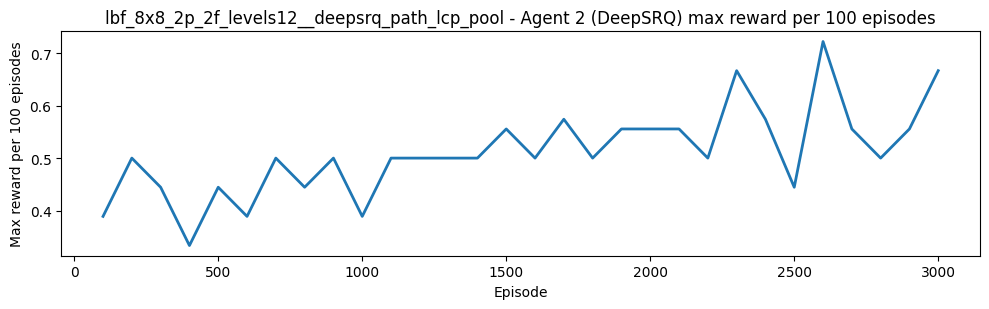

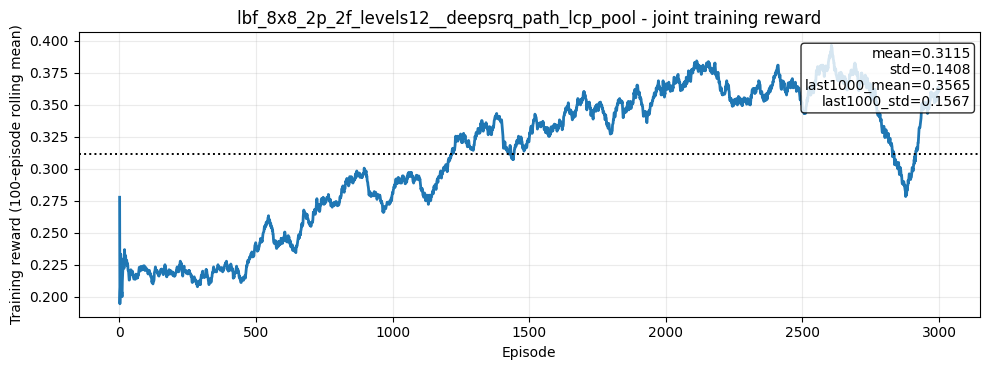

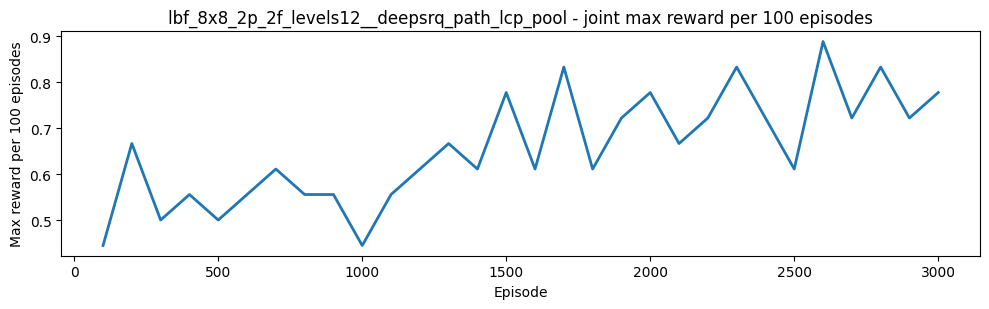

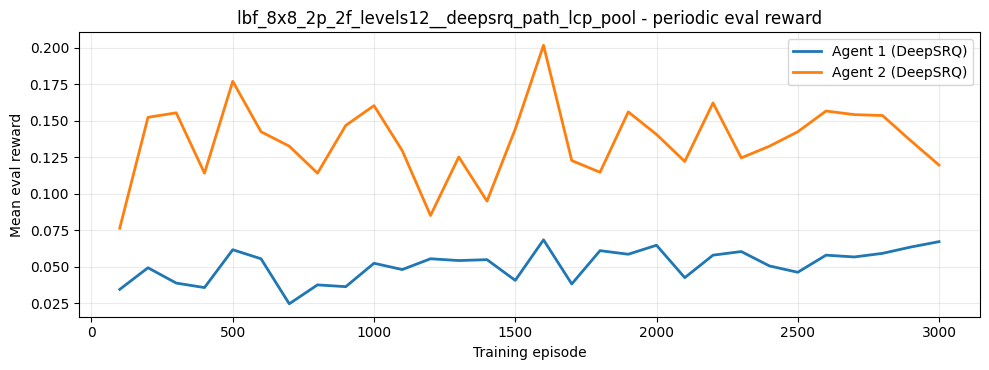

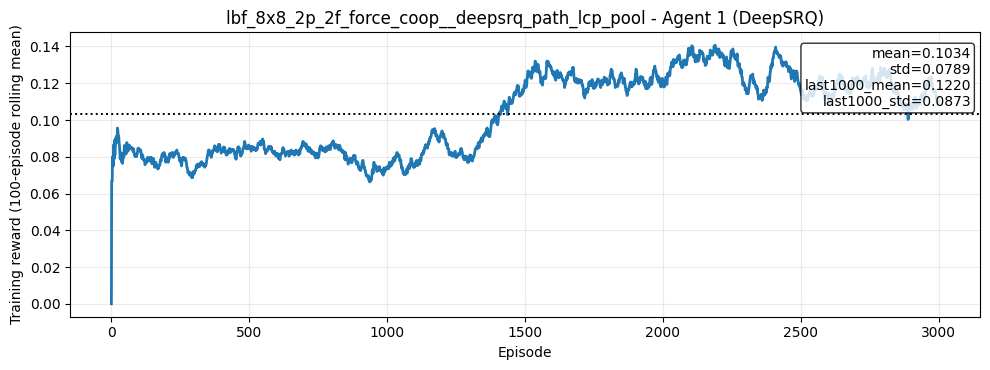

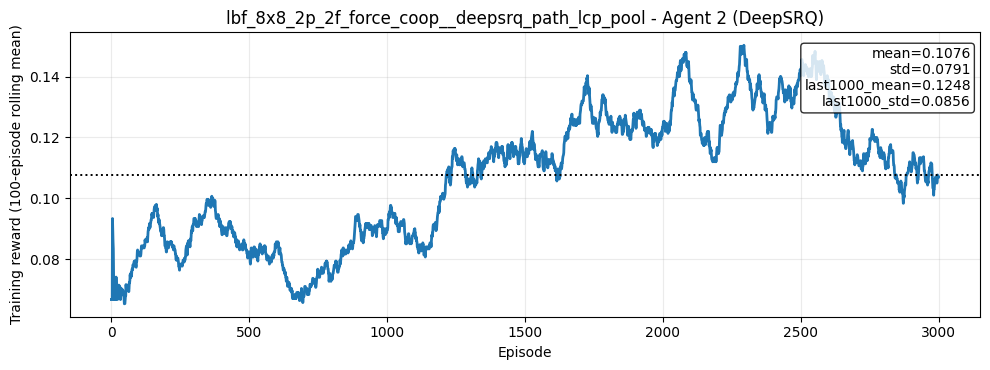

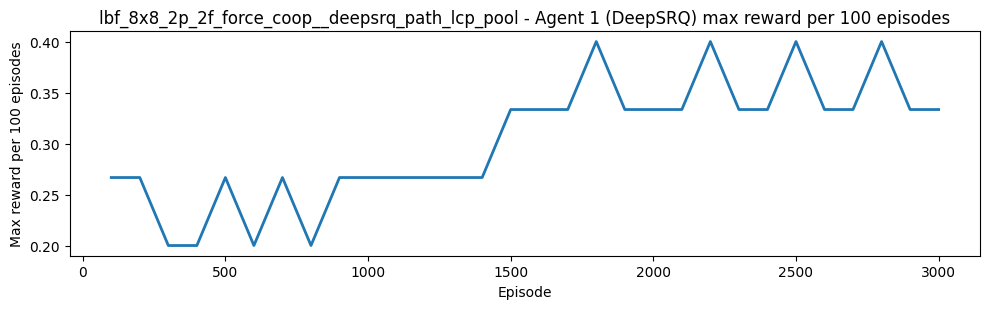

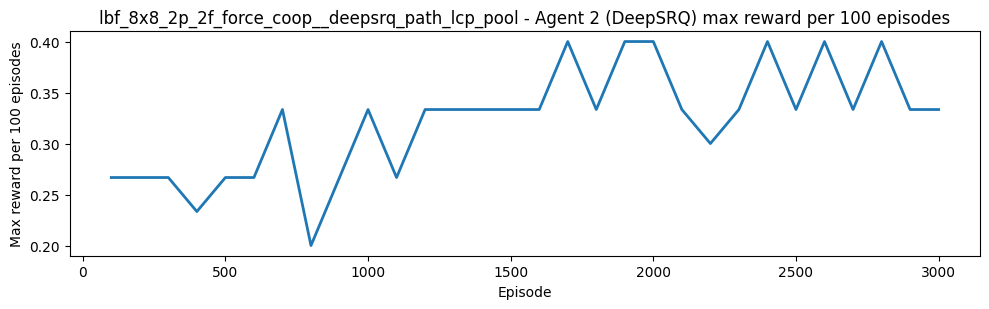

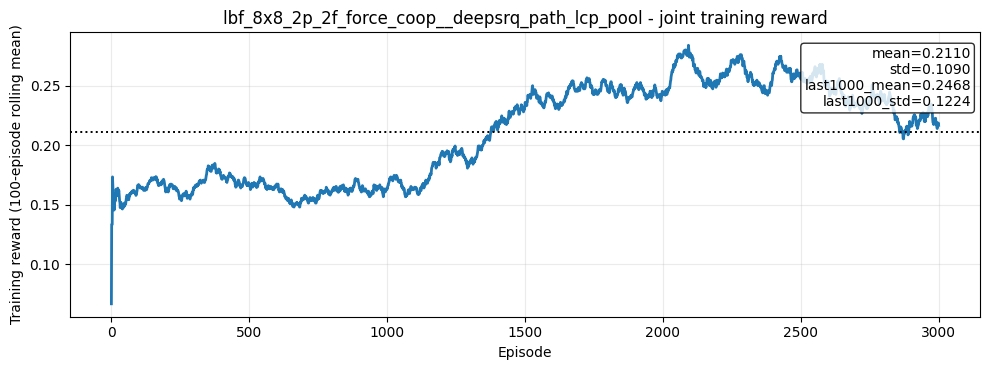

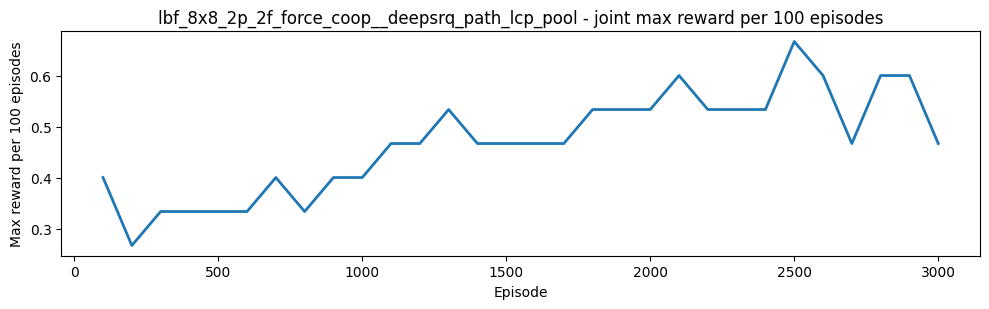

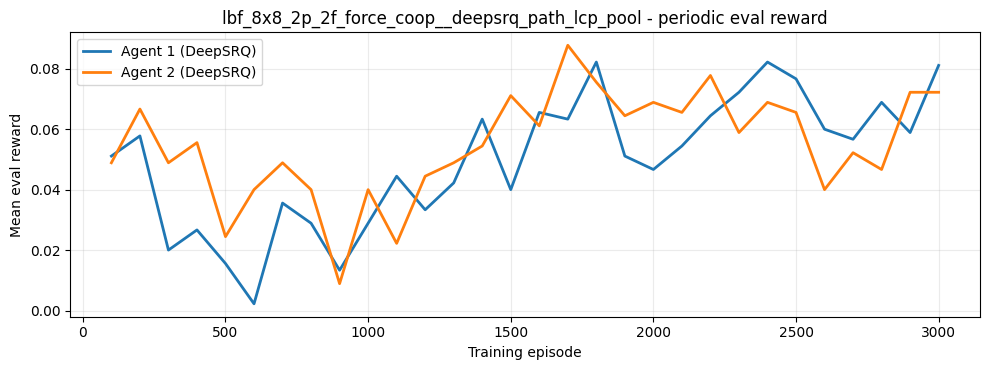

In [6]:
deep_srq_path_pool_eps_1_0_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    1.0,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 100,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_SOLVER,
    hyperparameter_overrides=PATH_C_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
)
deep_srq_path_pool_eps_1_0_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_1_0_stats.values()))


LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.5 | schedule=linear | seed=2525 | num_envs=32 | action_masks=True | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.5_linear:vec:   4%|█▋                                           | 116/3000 [01:01<24:32,  1.96it/s]

[ep   100] train_joint=  0.2094 | eval_joint=  0.1556 | best_loss=0.001065 | latest_loss=0.002743 | solver_mean_ms=23.473


lbf:path_c_pool_eps0.5_linear:vec:   7%|███▏                                         | 216/3000 [01:53<23:11,  2.00it/s]

[ep   200] train_joint=  0.2161 | eval_joint=  0.1815 | best_loss=0.000680 | latest_loss=0.001206 | solver_mean_ms=22.842


...

[ep  2900] train_joint=  0.2453 | eval_joint=  0.0956 | best_loss=0.000011 | latest_loss=0.000084 | solver_mean_ms=20.015


lbf:path_c_pool_eps0.5_linear:vec:  99%|███████████████████████████████████████████▋| 2981/3000 [25:35<00:10,  1.74it/s]

[ep  3000] train_joint=  0.2720 | eval_joint=  0.0800 | best_loss=0.000011 | latest_loss=0.000086 | solver_mean_ms=20.100


lbf:path_c_pool_eps0.5_linear:vec: 100%|████████████████████████████████████████████| 3000/3000 [25:39<00:00,  1.95it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 0.11 | 0.08 | 0.13             | 0.09            | 3000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 0.12 | 0.08 | 0.13             | 0.09            | 3000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool run=decay_0.5_to_0 ep=3000 best_loss=1.0779582225950435e-05 latest_loss=8.

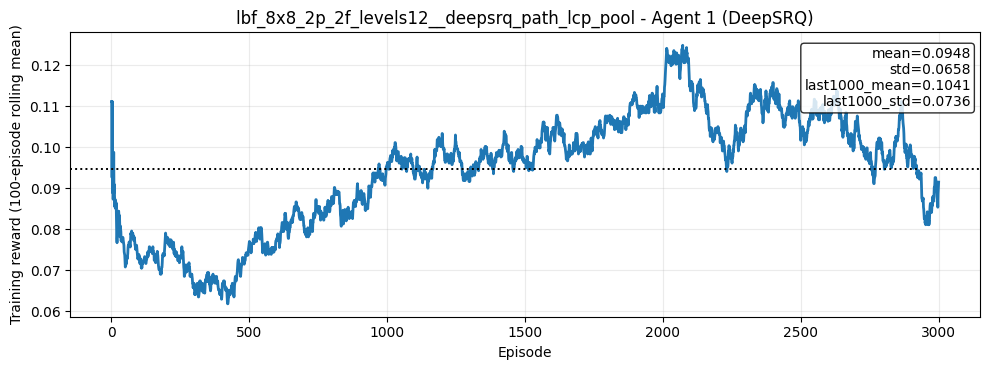

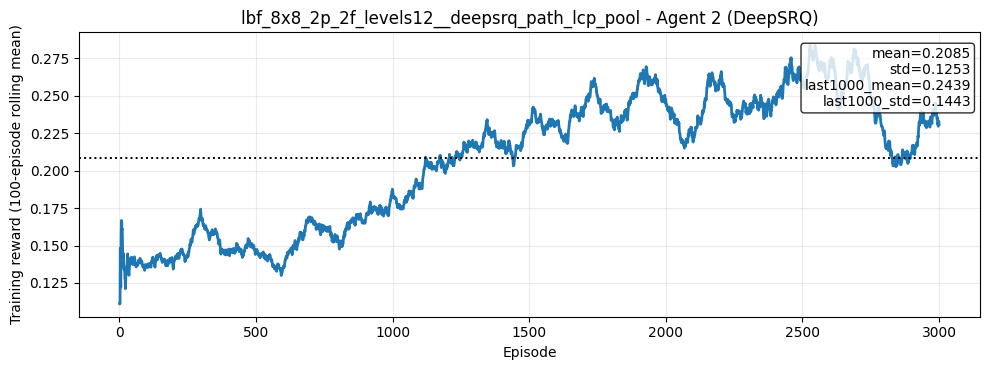

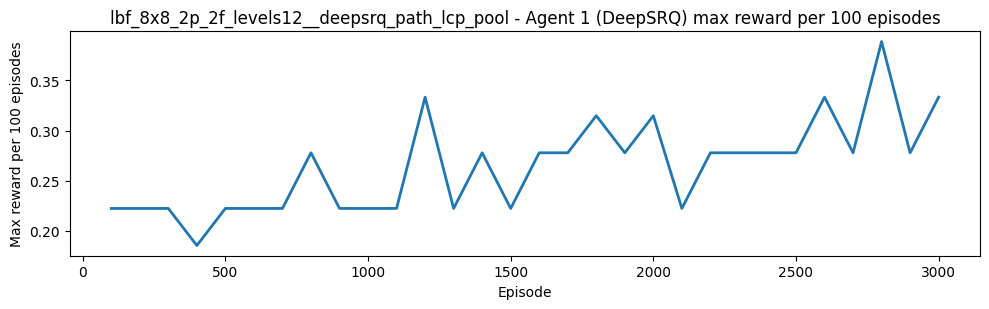

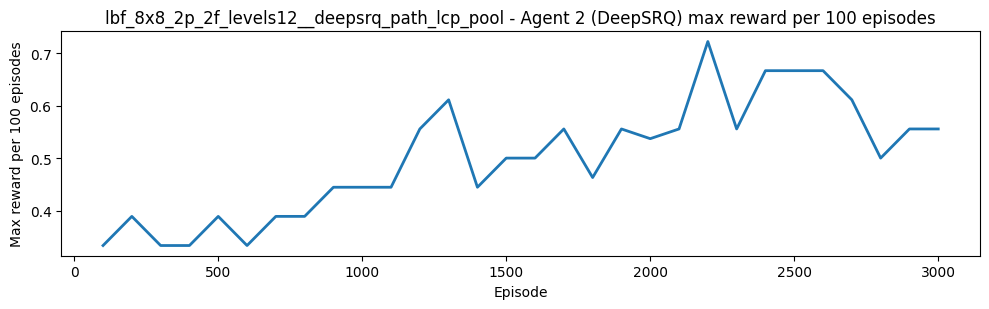

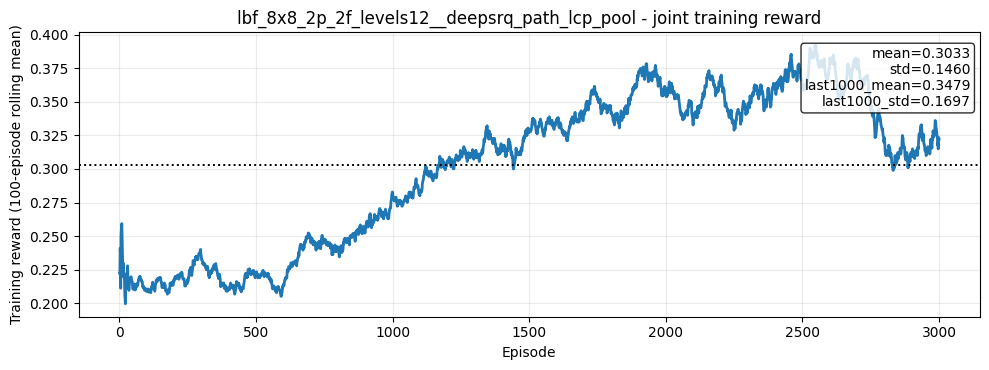

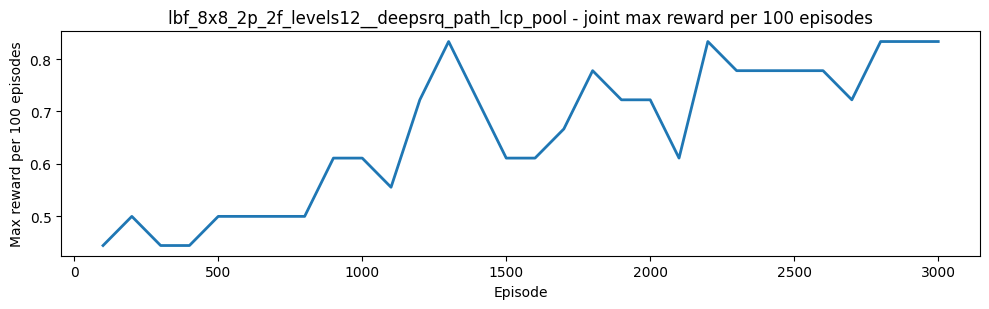

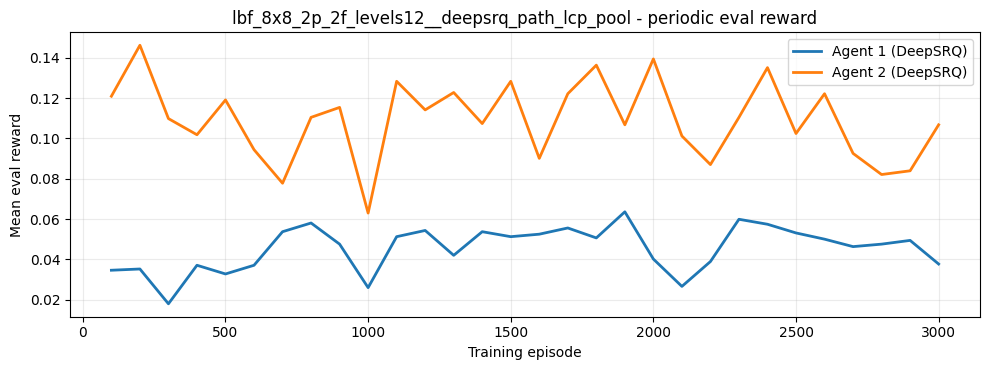

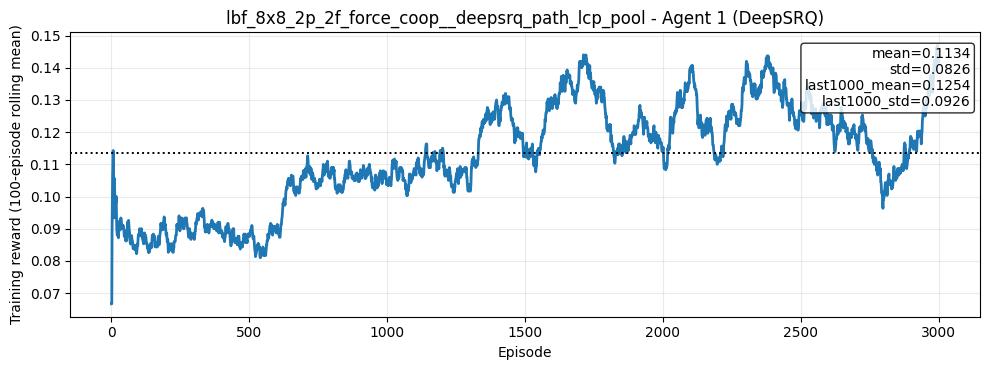

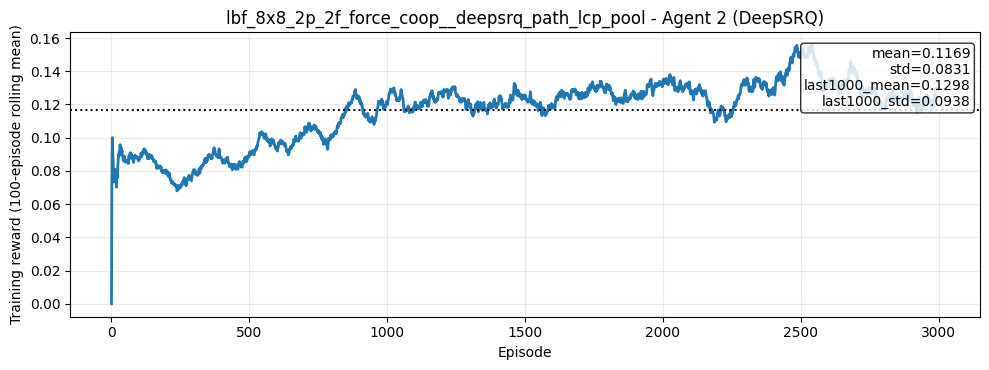

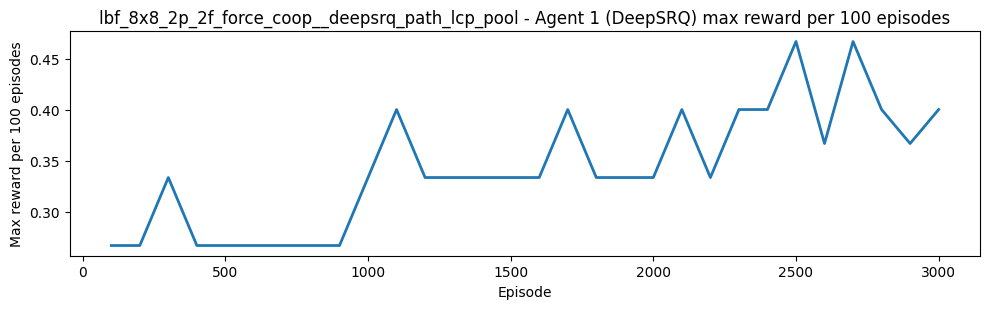

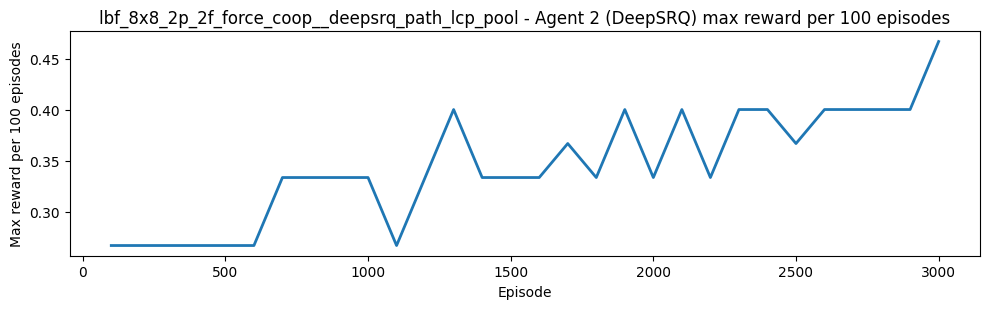

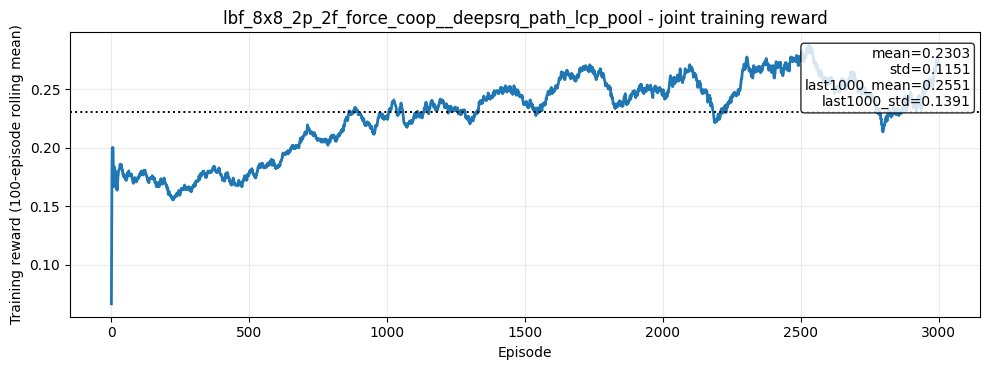

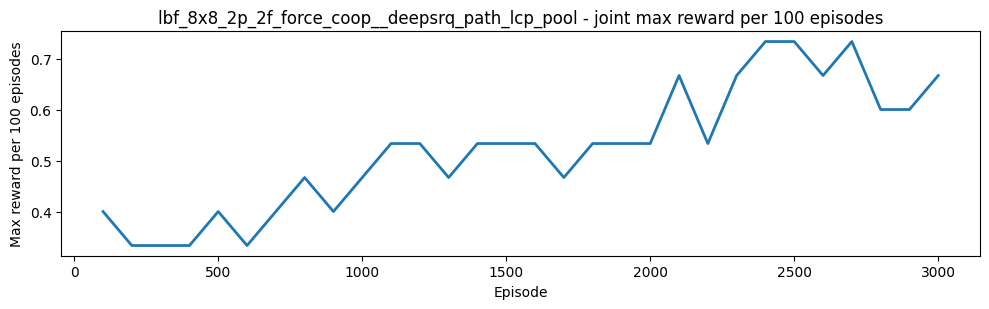

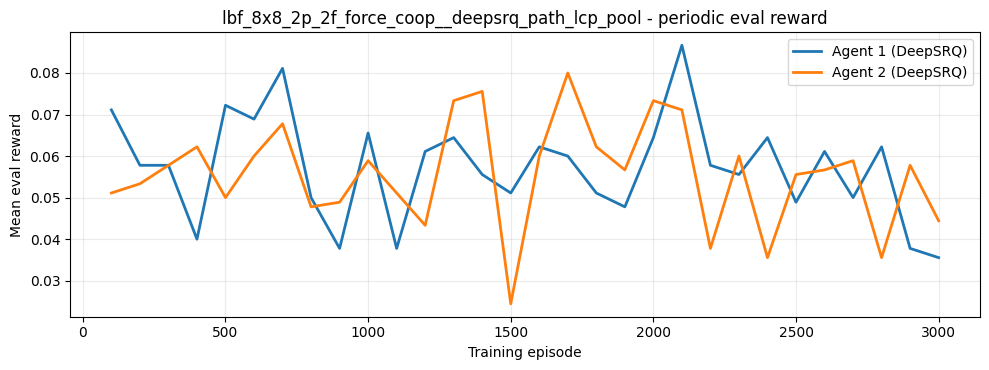

In [4]:
# Robust epsilon decay: 0.5 -> 0.0
deep_srq_path_pool_decay_0_5_to_0_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.5,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 500,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_SOLVER,
    hyperparameter_overrides=PATH_C_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
    epsilon_schedule="linear",
    run_name="decay_0.5_to_0",
    manifest_name="manifest_decay_0.5_to_0.json",
)
deep_srq_path_pool_decay_0_5_to_0_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_decay_0_5_to_0_stats.values()))


LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=1 | schedule=linear | seed=3025 | num_envs=32 | action_masks=True | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps1_linear:vec:   4%|█▊                                             | 115/3000 [01:00<22:42,  2.12it/s]

[ep   100] train_joint=  0.2050 | eval_joint=  0.1815 | best_loss=0.001078 | latest_loss=0.002676 | solver_mean_ms=21.014


lbf:path_c_pool_eps1_linear:vec:   7%|███▍                                           | 216/3000 [01:49<20:07,  2.31it/s]

[ep   200] train_joint=  0.2300 | eval_joint=  0.1574 | best_loss=0.000480 | latest_loss=0.000969 | solver_mean_ms=20.394


...

[ep  2900] train_joint=  0.2360 | eval_joint=  0.0978 | best_loss=0.000015 | latest_loss=0.000398 | solver_mean_ms=20.172


lbf:path_c_pool_eps1_linear:vec:  99%|█████████████████████████████████████████████▋| 2977/3000 [25:51<00:15,  1.51it/s]

[ep  3000] train_joint=  0.2587 | eval_joint=  0.0978 | best_loss=0.000013 | latest_loss=0.000048 | solver_mean_ms=20.265


lbf:path_c_pool_eps1_linear:vec: 100%|██████████████████████████████████████████████| 3000/3000 [25:56<00:00,  1.93it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 0.11 | 0.08 | 0.13             | 0.10            | 3000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 0.12 | 0.08 | 0.13             | 0.09            | 3000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool run=decay_1_to_0 ep=3000 best_loss=1.263304420717759e-05 latest_loss=4.807

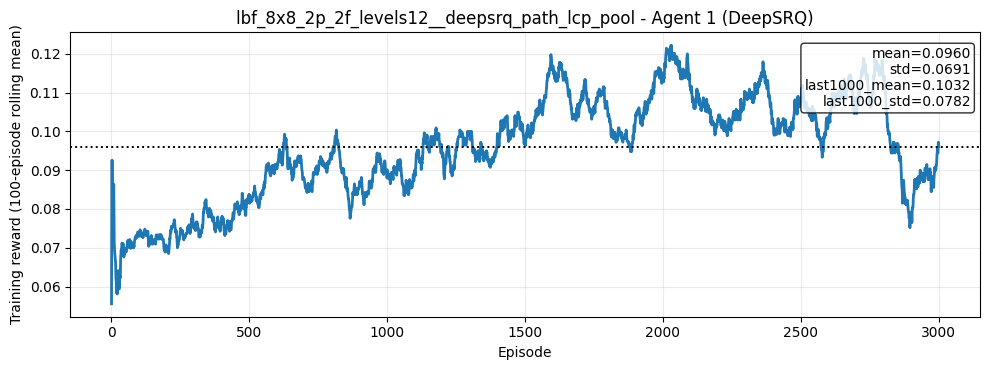

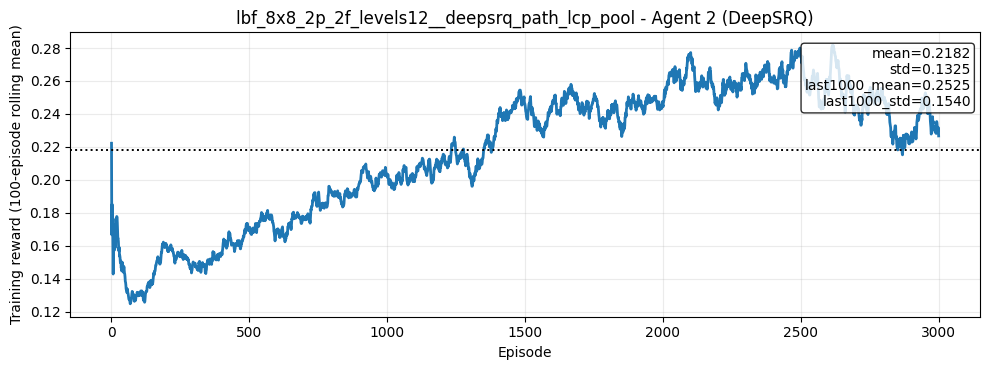

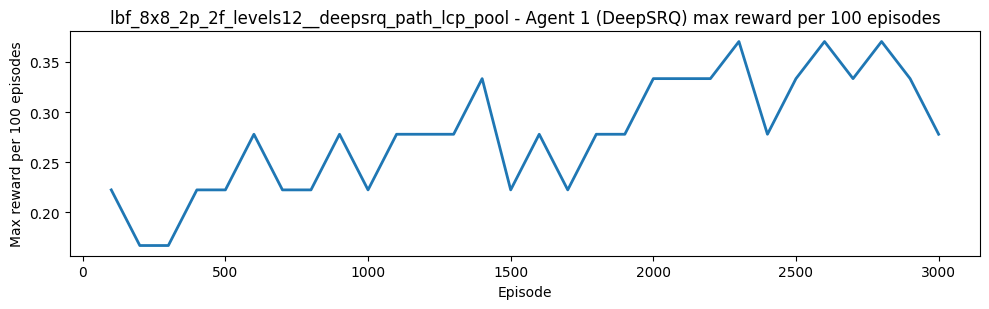

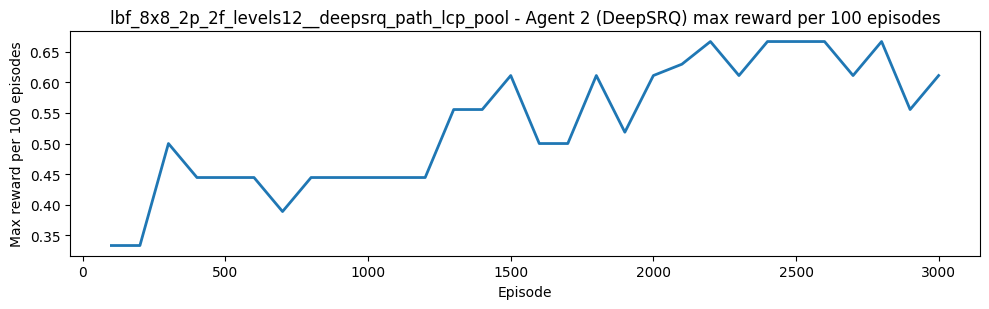

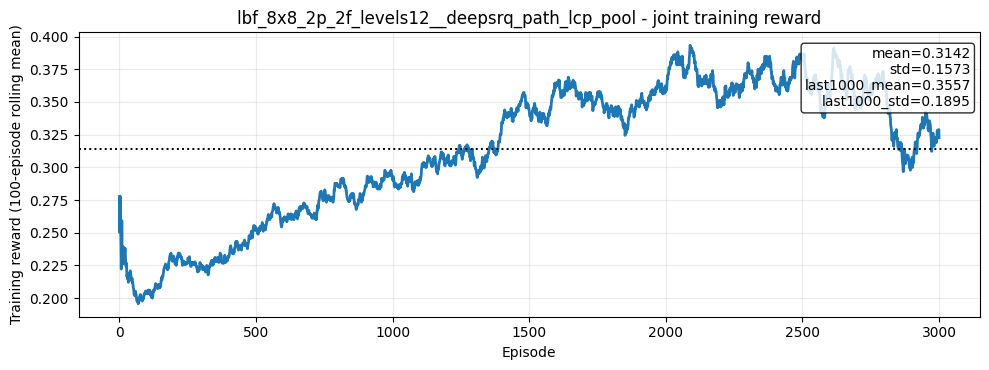

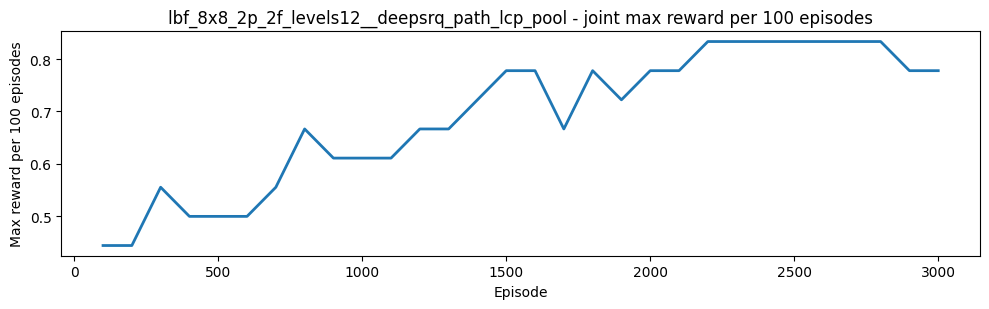

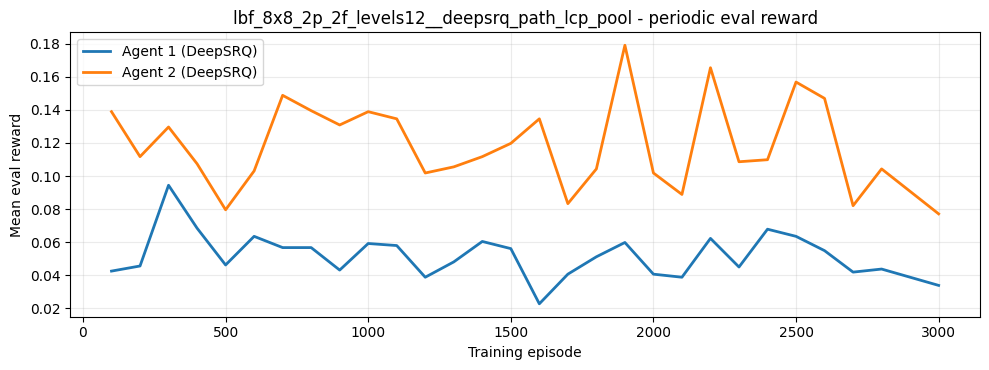

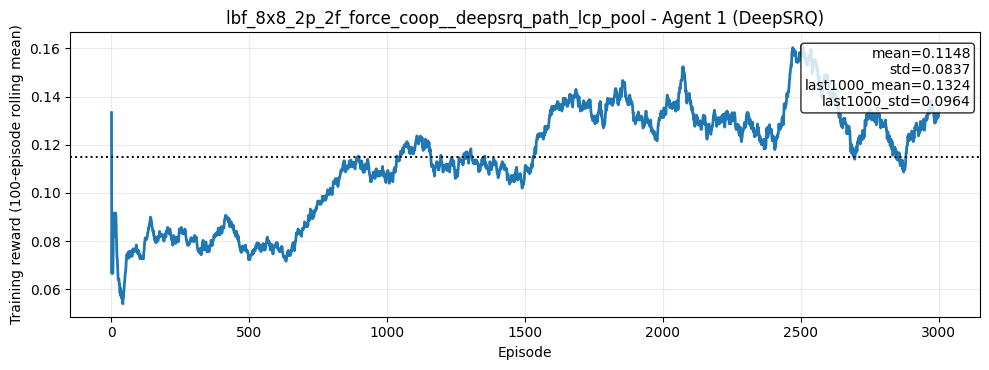

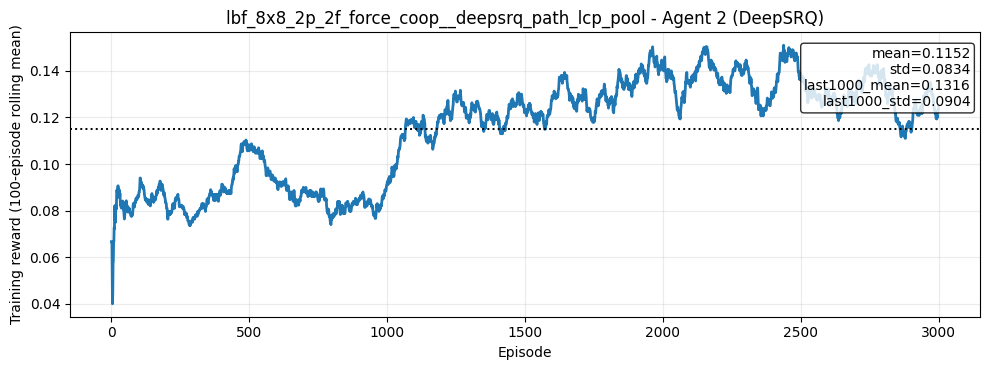

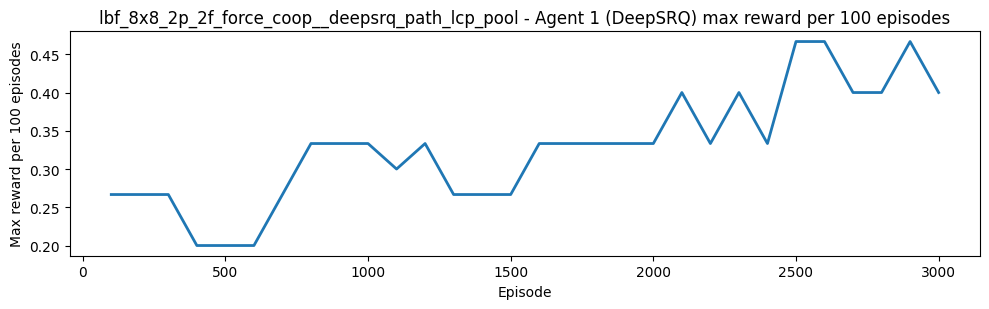

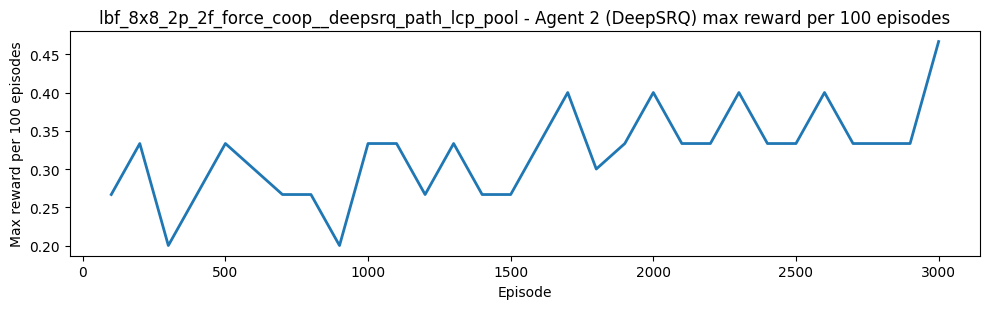

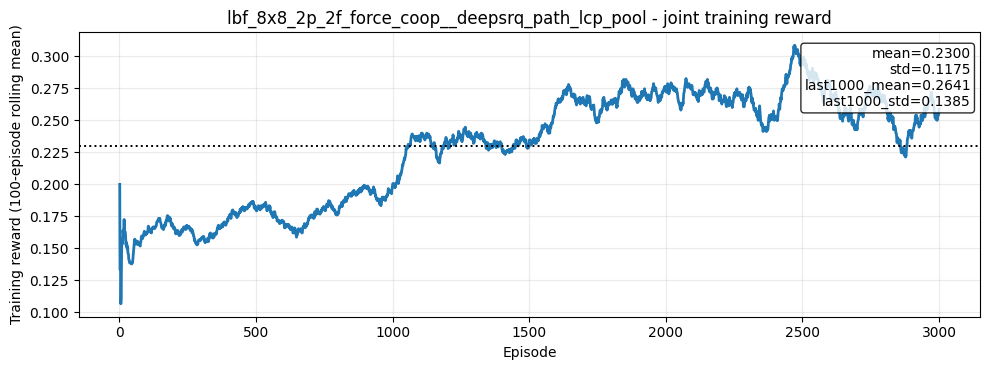

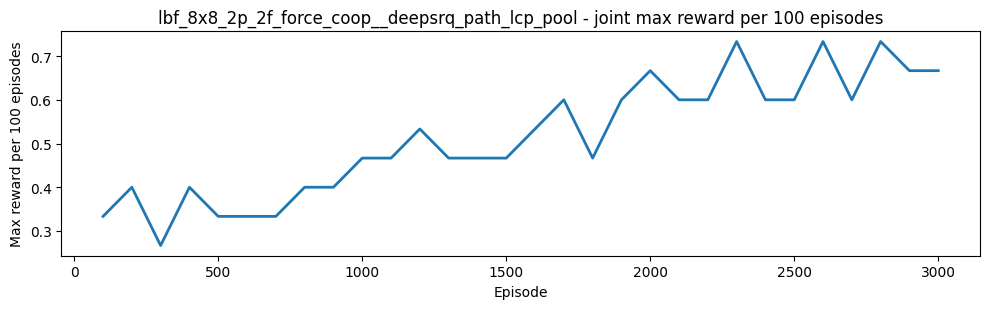

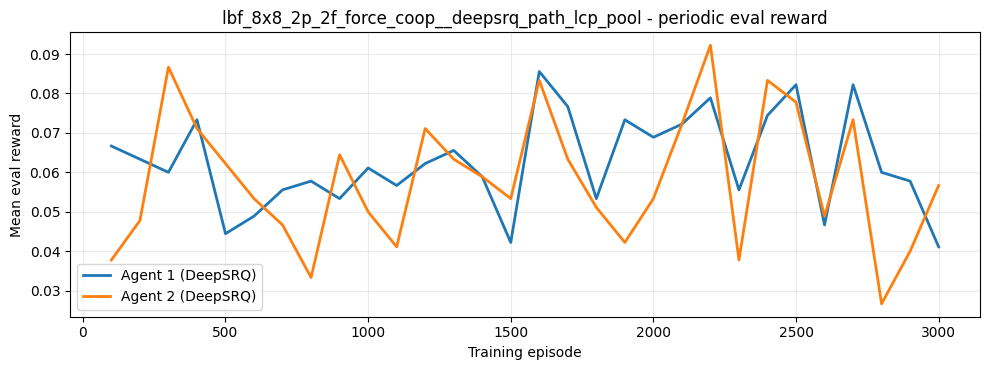

In [5]:
# Robust epsilon decay: 1.0 -> 0.0
deep_srq_path_pool_decay_1_0_to_0_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    1.0,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 1000,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_SOLVER,
    hyperparameter_overrides=PATH_C_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
    epsilon_schedule="linear",
    run_name="decay_1_to_0",
    manifest_name="manifest_decay_1_to_0.json",
)
deep_srq_path_pool_decay_1_0_to_0_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_decay_1_0_to_0_stats.values()))
